# Week 1: Team benchmark and improved retrieval

Global, single-resolution 1D color histograms only. QSD1 is used for evaluation; QST1 is blind and is used only to produce ranked submissions.

In [2]:
from pathlib import Path
import pickle
import sys

import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src import ColorHistogramRetrieval, load_ground_truth, load_image_dataset
from src.color_histogram_retrieval import read_rgb
from src.methods import AUDIT_METHODS, IMPROVED_TUNED, SUBMISSION_METHODS

database = load_image_dataset(ROOT / 'data/BBDD')
qsd1 = load_image_dataset(ROOT / 'data/qsd1_w1')
qst1 = load_image_dataset(ROOT / 'data/qst1_w1')
ground_truth = load_ground_truth(ROOT / 'data/qsd1_w1/gt_corresps.pkl')
print(f'Database: {len(database)} | QSD1: {len(qsd1)} | QST1: {len(qst1)}')

Database: 287 | QSD1: 30 | QST1: 30


## Team work consolidated

- Grayscale and stacked RGB were useful baselines but remained below the color-space methods.
- The common notebook added HSV/Lab concatenation, bin and smoothing searches, and a neighbour-averaged selection heuristic.
- This notebook uses one sorted-ID evaluator for every method and removes duplicate metric interpretations.

### Colour-space observations

- **Grayscale** loses colour information and reached only 0.300 top-1.
- **RGB** preserved colour but remained sensitive to brightness and channel changes; stacked RGB reached 0.367 top-1.
- **HSV** separated colour from brightness and produced the team's strongest original result: 0.567 mAP@1.
- **Lab** separated lightness from two chromatic axes and performed best after expanding the bin search. YCrCb was competitive with the early baselines but remained below HSV and Lab.

In [3]:
rows = []
rankings_by_name = {}
for config in AUDIT_METHODS:
    retriever = ColorHistogramRetrieval(config).fit(database)
    metrics, rankings = retriever.evaluate(qsd1, ground_truth)
    rankings_by_name[config.name] = rankings
    rows.append({
        'method': config.name,
        'space': config.color_space.upper(),
        'bins': config.bins,
        'sigma': config.sigma,
        'metric': config.metric,
        'weights': config.channel_weights,
        **metrics,
    })

results = pd.DataFrame(rows)
display(results.round(3))

,method,space,bins,sigma,metric,weights,mAP@1,mAP@5,top5_hit_rate
0,Individual RGB-G (original experiment),RGB,16,0.5,hellinger,"(0.0, 1.0, 0.0)",0.333,0.357,0.400
1,Team HSV robust selection,HSV,32,1.0,l1,"(0.3333333333333333, 0.3333333333333333, 0.333...",0.500,0.596,0.767
2,Team Lab robust selection,LAB,64,0.0,l1,"(0.3333333333333333, 0.3333333333333333, 0.333...",0.533,0.599,0.733
3,Team HSV best observed,HSV,16,0.5,l1,"(0.3333333333333333, 0.3333333333333333, 0.333...",0.567,0.629,0.767
4,Improved Lab - simple,LAB,40,0.0,l1,"(0.3333333333333333, 0.3333333333333333, 0.333...",0.633,0.662,0.733
5,Improved Lab - tuned,LAB,48,0.5,hellinger,"(0.125, 0.5, 0.375)",0.700,0.728,0.800


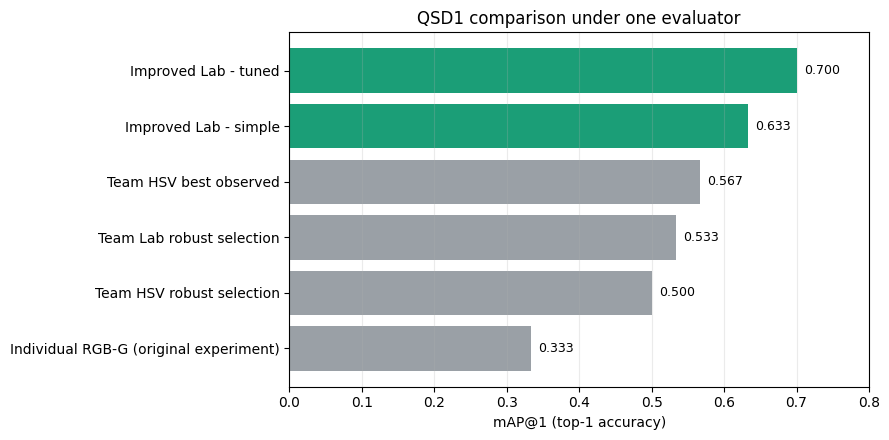

In [4]:
plot = results.sort_values('mAP@1')
fig, axis = plt.subplots(figsize=(9, 4.5))
colors = ['#9AA0A6' if 'Improved' not in name else '#1B9E77' for name in plot.method]
axis.barh(plot.method, plot['mAP@1'], color=colors)
for row, value in enumerate(plot['mAP@1']):
    axis.text(value + 0.01, row, f'{value:.3f}', va='center', fontsize=9)
axis.set(xlabel='mAP@1 (top-1 accuracy)', xlim=(0, 0.8), title='QSD1 comparison under one evaluator')
axis.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

## Findings and weighting rationale

- **Simple Lab:** 40 bins, equal channel weights and L1 distance reach **0.633 mAP@1**. This is the easier result to explain and reproduce.
- **Tuned Lab:** 48 bins, light smoothing and Hellinger distance reach **0.700 mAP@1**. Each channel is normalized before concatenation; weights therefore control channel influence rather than image size.
- The tuned weights `(L, a, b) = (0.125, 0.5, 0.375)` reduce sensitivity to illumination through `L` and emphasize the more discriminative chromatic axes `a` and `b`.

The weights were selected on only 30 QSD1 queries, so the gain is exploratory and QST1 may behave differently.

## Retrieval examples: improved method

Ten evenly spaced queries with the top-5 database results. Green marks a correct database ID.

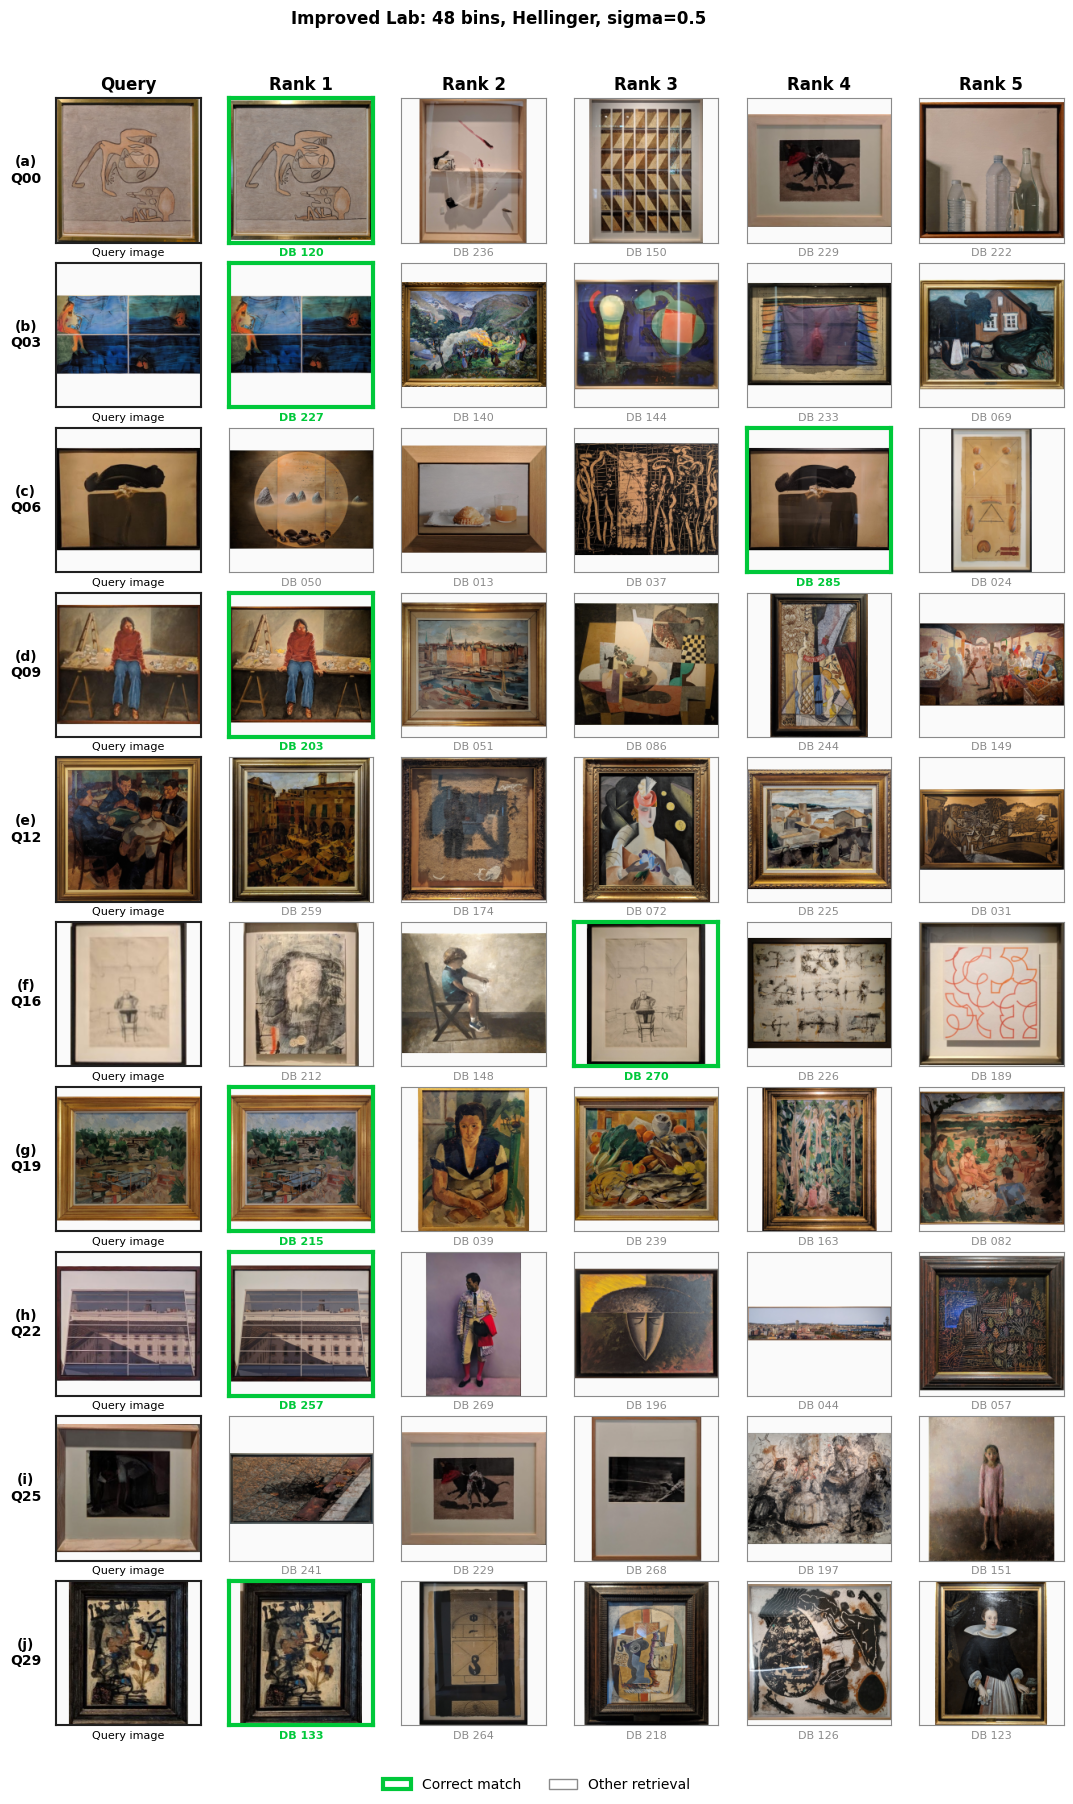

In [5]:
def square_thumbnail(path, size=180, background=250):
    image = read_rgb(path)
    height, width = image.shape[:2]
    scale = min(size / width, size / height)
    target = (max(1, round(width * scale)), max(1, round(height * scale)))
    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_CUBIC
    resized = cv2.resize(image, target, interpolation=interpolation)
    canvas = np.full((size, size, 3), background, dtype=np.uint8)
    top = (size - resized.shape[0]) // 2
    left = (size - resized.shape[1]) // 2
    canvas[top:top + resized.shape[0], left:left + resized.shape[1]] = resized
    return canvas

def style_axis(axis, color, width):
    axis.set_xticks([]); axis.set_yticks([])
    for spine in axis.spines.values():
        spine.set_color(color); spine.set_linewidth(width); spine.set_visible(True)

db_path = dict(zip(database.ids, database.paths))
query_indices = np.linspace(0, len(qsd1) - 1, 10, dtype=int)
rankings = rankings_by_name[IMPROVED_TUNED.name]
fig, axes = plt.subplots(10, 6, figsize=(12, 18), dpi=100, facecolor='white')
for row, query_index in enumerate(query_indices):
    correct = set(ground_truth[query_index])
    query_axis = axes[row, 0]
    query_axis.imshow(square_thumbnail(qsd1.paths[query_index]))
    query_axis.set_ylabel(f'({chr(97 + row)})\nQ{qsd1.ids[query_index]:02d}', rotation=0, labelpad=22, va='center', fontweight='bold')
    query_axis.set_xlabel('Query image', fontsize=8)
    style_axis(query_axis, '#202020', 1.5)
    for rank, image_id in enumerate(rankings[query_index, :5], start=1):
        axis = axes[row, rank]
        is_correct = int(image_id) in correct
        color = '#00C83A' if is_correct else '#8A8A8A'
        axis.imshow(square_thumbnail(db_path[int(image_id)]))
        axis.set_xlabel(f'DB {int(image_id):03d}', fontsize=8, color=color, fontweight='bold' if is_correct else 'normal')
        style_axis(axis, color, 3 if is_correct else 0.8)
    if row == 0:
        query_axis.set_title('Query', fontweight='bold')
        for rank in range(1, 6):
            axes[row, rank].set_title(f'Rank {rank}', fontweight='bold')
legend = [
    Patch(edgecolor='#00C83A', facecolor='white', linewidth=3, label='Correct match'),
    Patch(edgecolor='#8A8A8A', facecolor='white', linewidth=1, label='Other retrieval'),
]
fig.legend(handles=legend, loc='lower center', ncol=2, frameon=False)
fig.suptitle('Improved Lab: 48 bins, Hellinger, sigma=0.5', y=0.995, fontweight='bold')
plt.tight_layout(rect=(0.07, 0.025, 1, 0.985), h_pad=0.35, w_pad=0.25)
plt.show()

## QST1 submission

In [6]:
submission_root = ROOT / 'submissions/Team3/week1/QST1'
for method_name, config in SUBMISSION_METHODS.items():
    path = submission_root / method_name / 'result.pkl'
    with path.open('rb') as stream:
        predictions = pickle.load(stream)
    assert len(predictions) == 30 and all(len(row) == 10 for row in predictions)
    print(f'{method_name}: {config.name}')
    print(' shape:', (len(predictions), len(predictions[0])), '| first query:', predictions[0])

method1: Improved Lab - simple
 shape: (30, 10) | first query: [27, 276, 225, 82, 239, 149, 174, 259, 51, 31]
method2: Improved Lab - tuned
 shape: (30, 10) | first query: [276, 259, 51, 174, 27, 225, 235, 4, 29, 137]


## Reusable structure

```text
src/color_histogram_retrieval.py  # Week 1 descriptor class
src/data.py, distances.py, evaluation.py  # shared by later weeks
scripts/evaluate_week1.py
scripts/generate_qst1.py
submissions/Team3/week1/QST1/{method1,method2}/result.pkl
```

To add a method, define one `HistogramConfig`; the evaluator and QST1 writer stay unchanged.